# Stochastic Interest Rate Modelling and Prediction
## Cox-Ingersoll-Ross (CIR) Model: Implementation, Calibration & Extension
### Finance Club, IIT Roorkee — Open Projects 2026

---

**Author:** *Aditya Kumar Pandit*  
**Date:** June 2026

---

## Overview

This notebook implements, calibrates, and extends the **Cox-Ingersoll-Ross (CIR)** short-rate model on real historical zero-coupon bond yield data. The workflow follows five stages:

| Stage | Description |
|-------|-------------|
| A | Data Engineering & Preprocessing |
| B | Base CIR Model: Implementation & OLS Calibration |
| C | Prediction Challenge: Yield Curve Construction from 3M Rate |
| D | Extension: CIR++ with Static λ Shift |
| E | Critical Analysis & Conclusions |

The target metric is **out-of-sample R² > 0.85** when reconstructing the full yield curve from only the 3-Month rate.


---
## A. Data Engineering and Preprocessing

### A.1 Imports and Setup


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import minimize, differential_evolution
from scipy.interpolate import CubicSpline
from scipy.stats import zscore
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')
# Plotting aesthetics
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

print("All libraries loaded successfully.")


Mounted at /content/drive
All libraries loaded successfully.


### A.2 Load Data

The dataset contains daily zero-coupon bond yields across 9 maturities:
**3M, 6M, 9M, 1Y, 2Y, 5Y, 10Y, 20Y, 30Y** (training set), and **3M–2Y** (test set).

> **Note:** Upload `train_data.csv`, `test_data.csv`, and `test_data_3M.csv` to your Google Drive under a `project/` folder and mount below, or upload directly to the Colab session.


In [ ]:
# ── Load Data ──
TRAIN_PATH  = '/content/drive/MyDrive/project/train_data.csv'
TEST_PATH   = '/content/drive/MyDrive//project/test_data.csv'
TEST_3M_PATH = '/content/drive/MyDrive/project/test_data_3M.csv'

def load_yield_data(path: str) -> pd.DataFrame:
    """Load a yield CSV, strip whitespace from column names, parse dates."""
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date').sort_index()
    return df

train_raw  = load_yield_data(TRAIN_PATH)
test_raw   = load_yield_data(TEST_PATH)
test3m_raw = load_yield_data(TEST_3M_PATH)

print(f"Training set : {train_raw.shape}  | {train_raw.index[0].date()} → {train_raw.index[-1].date()}")
print(f"Test set     : {test_raw.shape}  | {test_raw.index[0].date()} → {test_raw.index[-1].date()}")
print(f"Test 3M only : {test3m_raw.shape}")
print()
print("Training columns:", train_raw.columns.tolist())
print("Test columns    :", test_raw.columns.tolist())


Training set : (1976, 9)  | 2016-05-19 → 2024-04-26
Test set     : (495, 5)  | 2024-04-29 → 2026-04-29
Test 3M only : (495, 1)

Training columns: ['ZC025YR', 'ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR', 'ZC500YR', 'ZC1000YR', 'ZC2000YR', 'ZC3000YR']
Test columns    : ['ZC025YR', 'ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR']


### A.3 Maturity Mapping

The column names encode maturities in years multiplied by 100 (e.g., `ZC025YR` = 0.25 years = 3 months).


In [ ]:
# ── Maturity definitions ──
MATURITY_MAP = {
    'ZC025YR': 0.25,   # 3 Months
    'ZC050YR': 0.50,   # 6 Months
    'ZC075YR': 0.75,   # 9 Months
    'ZC100YR': 1.00,   # 1 Year
    'ZC200YR': 2.00,   # 2 Years
    'ZC500YR': 5.00,   # 5 Years
    'ZC1000YR': 10.00, # 10 Years
    'ZC2000YR': 20.00, # 20 Years
    'ZC3000YR': 30.00, # 30 Years
}

TRAIN_MATURITIES = np.array([0.25, 0.50, 0.75, 1.00, 2.00, 5.00, 10.00, 20.00, 30.00])
TEST_MATURITIES  = np.array([0.50, 0.75, 1.00, 2.00])  # 3M is input; predict the rest

TRAIN_COLS = ['ZC025YR','ZC050YR','ZC075YR','ZC100YR','ZC200YR',
              'ZC500YR','ZC1000YR','ZC2000YR','ZC3000YR']
TEST_COLS  = ['ZC050YR','ZC075YR','ZC100YR','ZC200YR']

MATURITY_LABELS = {
    0.25: '3M', 0.50: '6M', 0.75: '9M', 1.00: '1Y',
    2.00: '2Y', 5.00: '5Y', 10.00: '10Y', 20.00: '20Y', 30.00: '30Y'
}


### A.4 Data Cleaning

Although no missing values were found in the raw files, we apply a rigorous cleaning pipeline:
1. **Missing value imputation** — forward-fill then linear interpolation for any gaps.
2. **Outlier detection** — flag observations where the z-score exceeds ±4 (within each column), and replace with the column median. This is conservative enough to preserve genuine regime shifts while removing data errors.
3. **Positivity enforcement** — clip any non-positive yields to a small floor (1 bp), since the CIR model is undefined for r ≤ 0.


In [ ]:
def clean_yield_data(df: pd.DataFrame, z_thresh: float = 4.0) -> pd.DataFrame:
    """
    Clean a yield DataFrame:
      1. Forward-fill then interpolate missing values.
      2. Replace z-score outliers with column median.
      3. Clip yields to a positive floor.

    Parameters
    ----------
    df       : DataFrame of yields (rows = dates, cols = maturities).
    z_thresh : Z-score threshold above which a value is flagged as an outlier.

    Returns
    -------
    Cleaned DataFrame.
    """
    df = df.copy()

    # Step 1: Handle missing values
    missing_before = df.isnull().sum().sum()
    df = df.ffill().interpolate(method='linear')
    missing_after = df.isnull().sum().sum()
    print(f"  Missing values: {missing_before} before → {missing_after} after imputation")

    # Step 2: Outlier detection via rolling z-score
    outliers_total = 0
    for col in df.columns:
        z = np.abs(zscore(df[col].values, nan_policy='omit'))
        mask = z > z_thresh
        n_out = mask.sum()
        if n_out > 0:
            col_median = df[col].median()
            df.loc[mask, col] = col_median
            print(f"  Outliers replaced in {col}: {n_out} (→ median {col_median:.4f})")
        outliers_total += n_out
    print(f"  Total outliers replaced: {outliers_total}")

    # Step 3: Enforce positivity (CIR requires r > 0)
    floor = 1e-4  # 1 basis point
    clipped = (df < floor).sum().sum()
    df = df.clip(lower=floor)
    if clipped:
        print(f"  Clipped {clipped} non-positive values to floor={floor}")

    return df

print("Cleaning training data:")
train = clean_yield_data(train_raw[TRAIN_COLS])
print()
print("Cleaning test data:")
test = clean_yield_data(test_raw[TEST_COLS])
print()
print("Cleaning test 3M data:")
test3m = clean_yield_data(test3m_raw[['ZC025YR']])


Cleaning training data:
  Missing values: 0 before → 0 after imputation
  Total outliers replaced: 0

Cleaning test data:
  Missing values: 0 before → 0 after imputation
  Total outliers replaced: 0

Cleaning test 3M data:
  Missing values: 0 before → 0 after imputation
  Total outliers replaced: 0


In [ ]:
# ── Summary statistics ──
print("=== Training Data Summary (yields as decimals) ===")
display(train.describe().round(6))


=== Training Data Summary (yields as decimals) ===


,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
count,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000
mean,0.016699,0.017885,0.018529,0.019174,0.018063,0.018109,0.020226,0.022823,0.022619
std,0.016642,0.016760,0.016650,0.016587,0.013661,0.010396,0.008805,0.007136,0.006601
min,0.000486,0.000878,0.001054,0.001227,0.001417,0.002786,0.004451,0.008394,0.006921
25%,0.004622,0.005190,0.005449,0.005729,0.005897,0.009570,0.014451,0.017739,0.017895
50%,0.011912,0.013815,0.015304,0.016335,0.015471,0.015981,0.018905,0.022472,0.022258
75%,0.017112,0.019378,0.021077,0.022743,0.025553,0.026415,0.027340,0.028148,0.027408
max,0.051962,0.053195,0.054040,0.054940,0.048496,0.043147,0.042232,0.040687,0.039306


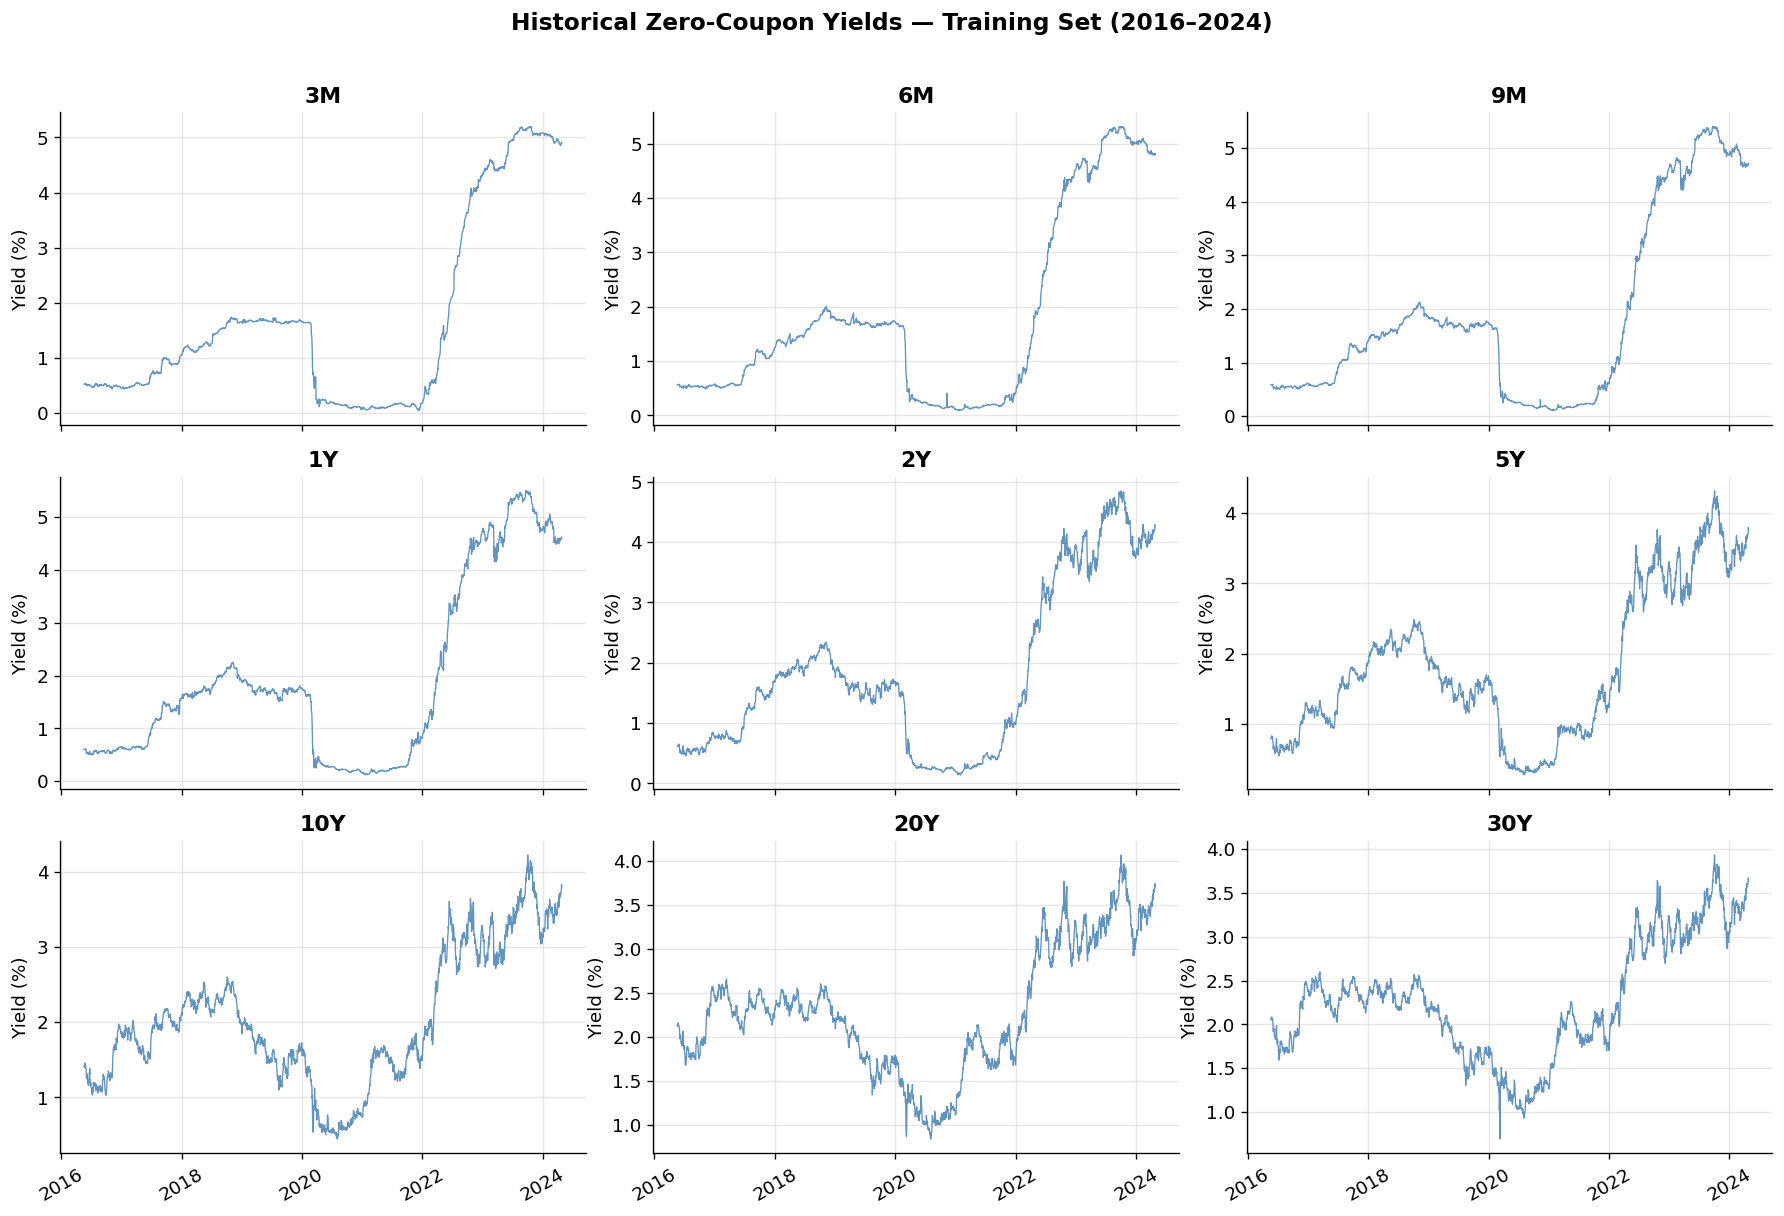

Figure saved.


In [ ]:
# ── Visualise the full yield history ──
fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True)
axes = axes.ravel()

for ax, col in zip(axes, TRAIN_COLS):
    tau = MATURITY_MAP[col]
    ax.plot(train.index, train[col] * 100, color='steelblue', lw=0.8, alpha=0.85)
    ax.set_title(MATURITY_LABELS[tau], fontweight='bold')
    ax.set_ylabel('Yield (%)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

fig.suptitle('Historical Zero-Coupon Yields — Training Set (2016–2024)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('yield_history.png', bbox_inches='tight')
plt.show()
print("Figure saved.")


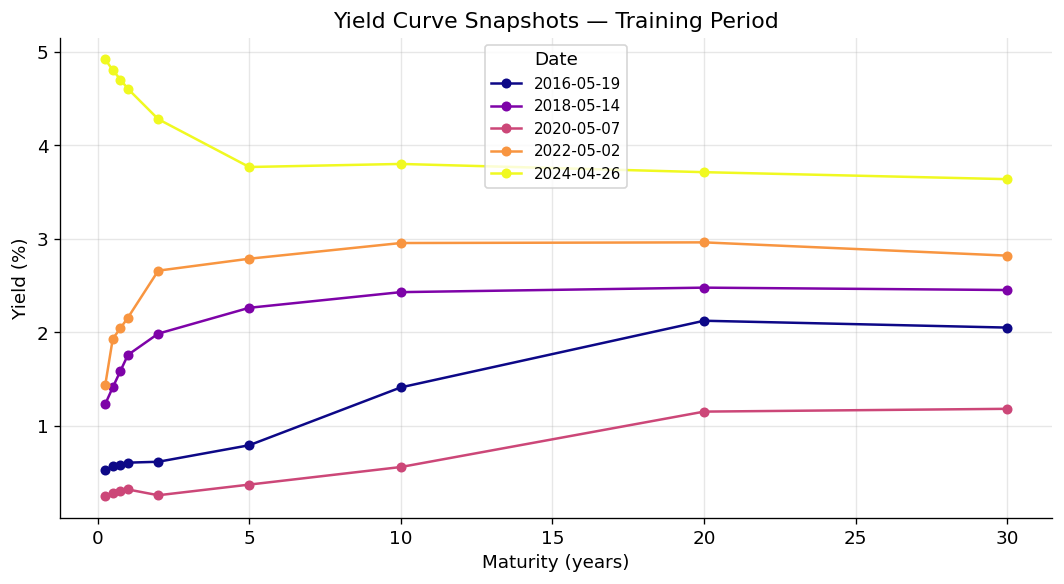

In [ ]:
# ── Plot full yield curve (snapshot on 5 equidistant dates) ──
snapshot_dates = pd.date_range(train.index[0], train.index[-1], periods=5)
snapshot_dates = [train.index[np.abs(train.index - d).argmin()] for d in snapshot_dates]

fig, ax = plt.subplots(figsize=(9, 5))
cmap = plt.cm.plasma
for j, d in enumerate(snapshot_dates):
    row = train.loc[d, TRAIN_COLS].values * 100
    ax.plot(TRAIN_MATURITIES, row, marker='o', ms=5,
            color=cmap(j / (len(snapshot_dates) - 1)),
            label=str(d.date()))
ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Yield (%)')
ax.set_title('Yield Curve Snapshots — Training Period')
ax.legend(title='Date', fontsize=9)
plt.tight_layout()
plt.savefig('yield_curve_snapshots.png', bbox_inches='tight')
plt.show()


---
## B. Base CIR Model — Implementation & OLS Calibration

### B.1 The CIR Stochastic Differential Equation

The Cox-Ingersoll-Ross (1985) model specifies the instantaneous short rate $r_t$ via:

$$dr_t = \kappa(\theta - r_t)\,dt + \sigma\sqrt{r_t}\,dW_t$$

| Parameter | Meaning |
|-----------|---------|
| $\kappa > 0$ | Speed of mean reversion |
| $\theta > 0$ | Long-run mean interest rate |
| $\sigma > 0$ | Volatility coefficient |
| $W_t$ | Standard Brownian motion |

The **Feller condition** $2\kappa\theta \geq \sigma^2$ guarantees that $r_t > 0$ a.s., which is critical for the square-root diffusion to remain well-defined.

### B.2 Closed-Form Bond Pricing and Yield Formula

The price of a zero-coupon bond with face value 1, observed at time $t$ and maturing at $T$, is:

$$P(t,T) = A(t,T)\,e^{-B(t,T)\,r_t}$$

where $\tau = T - t$ and $\gamma = \sqrt{\kappa^2 + 2\sigma^2}$:

$$B(\tau) = \frac{2(e^{\gamma\tau}-1)}{(\gamma+\kappa)(e^{\gamma\tau}-1) + 2\gamma}$$

$$\ln A(\tau) = \frac{2\kappa\theta}{\sigma^2}\ln\!\left(\frac{2\gamma\,e^{(\kappa+\gamma)\tau/2}}{(\gamma+\kappa)(e^{\gamma\tau}-1)+2\gamma}\right)$$

The **continuously compounded yield** for maturity $\tau$ is:

$$y(\tau) = -\frac{\ln P}{\tau} = \frac{B(\tau)\,r_t - \ln A(\tau)}{\tau}$$

### B.3 Calibration via Cross-Sectional OLS

**Why cross-sectional OLS?**

A purely time-series OLS on $\Delta r_t = \kappa\theta\,\Delta t - \kappa\,r_t\,\Delta t + \varepsilon_t$ (Euler linearisation) estimates parameters from a *single* maturity and is severely biased when $\kappa$ is small relative to the sampling interval — a well-known small-$\kappa$ bias in CIR estimation (Tang & Chen, 2009). Moreover, the short rate $r_t$ is latent; using the 3M yield as a proxy introduces measurement error that contaminate time-series estimates.

**Cross-sectional OLS** sidesteps these issues by treating the observed yield curve on each day as a signal and minimising the mean squared error (MSE) across *all maturities simultaneously*:

$$\hat{\kappa}, \hat{\theta}, \hat{\sigma} = \arg\min_{\kappa,\theta,\sigma} \frac{1}{T \cdot M}\sum_{t=1}^{T}\sum_{m=1}^{M}\left[y_{t,m}^{\text{obs}} - y(r_t^{3M}; \kappa, \theta, \sigma, \tau_m)\right]^2$$

This is a **global nonlinear least-squares** fit. The closed-form yield formula means no simulation is needed — the objective evaluates in O(T·M) time. We solve it with Nelder-Mead and additionally validate with Differential Evolution to ensure a global minimum.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CIR Model Core Functions
# ─────────────────────────────────────────────────────────────────

def cir_B(kappa: float, sigma: float, tau: np.ndarray) -> np.ndarray:
    """
    CIR bond-pricing function B(tau).

    Derived from the affine structure of the CIR model:
        gamma = sqrt(kappa^2 + 2*sigma^2)
        B(tau) = 2*(exp(gamma*tau) - 1) / [(gamma + kappa)*(exp(gamma*tau) - 1) + 2*gamma]

    Parameters
    ----------
    kappa : mean-reversion speed
    sigma : volatility
    tau   : array of maturities (in years)

    Returns
    -------
    B(tau) array
    """
    gamma = np.sqrt(kappa**2 + 2 * sigma**2)
    exp_gt = np.exp(gamma * tau)
    denom = (gamma + kappa) * (exp_gt - 1) + 2 * gamma
    return 2 * (exp_gt - 1) / denom


def cir_lnA(kappa: float, theta: float, sigma: float, tau: np.ndarray) -> np.ndarray:
    """
    CIR bond-pricing function ln A(tau).

        ln A(tau) = (2*kappa*theta / sigma^2) *
                    ln( 2*gamma*exp((kappa+gamma)*tau/2) / denom )

    Parameters
    ----------
    kappa, theta, sigma : CIR parameters
    tau                 : maturity array

    Returns
    -------
    ln A(tau) array
    """
    gamma = np.sqrt(kappa**2 + 2 * sigma**2)
    exp_gt = np.exp(gamma * tau)
    denom = (gamma + kappa) * (exp_gt - 1) + 2 * gamma
    numerator = 2 * gamma * np.exp((kappa + gamma) * tau / 2)
    return (2 * kappa * theta / sigma**2) * np.log(numerator / denom)


def cir_yield(r0: np.ndarray,
              kappa: float,
              theta: float,
              sigma: float,
              tau: np.ndarray) -> np.ndarray:
    """
    CIR zero-coupon yield for maturity(ies) tau given short rate r0.

        y(tau) = [B(tau)*r0 - ln A(tau)] / tau

    Parameters
    ----------
    r0    : array of short rates (shape T,) or scalar
    kappa, theta, sigma : CIR parameters
    tau   : maturity or array of maturities (in years)

    Returns
    -------
    yield array of shape (T, len(tau)) if both r0 and tau are arrays,
    or (T,) if tau is scalar.
    """
    r0  = np.asarray(r0, dtype=float)
    tau = np.asarray(tau, dtype=float)
    B   = cir_B(kappa, sigma, tau)
    lnA = cir_lnA(kappa, theta, sigma, tau)

    if r0.ndim == 1 and tau.ndim == 1:
        # Outer: (T,1) * (1,M) → (T,M)
        return (np.outer(r0, B) - lnA[np.newaxis, :]) / tau[np.newaxis, :]
    else:
        return (B * r0 - lnA) / tau


def feller_condition(kappa: float, theta: float, sigma: float) -> bool:
    """Return True if 2*kappa*theta >= sigma^2 (rates remain positive a.s.)."""
    return 2 * kappa * theta >= sigma**2


print("CIR functions defined.")


CIR functions defined.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Cross-Sectional OLS Calibration
# ─────────────────────────────────────────────────────────────────

class CIRCalibrator:
    """
    Calibrate CIR parameters (kappa, theta, sigma) by minimising the
    cross-sectional MSE across all training dates and maturities.

    The objective is a nonlinear least-squares problem solved with
    Nelder-Mead (fast, gradient-free) initialised at multiple starting
    points and validated with Differential Evolution (global search).
    """

    def __init__(self, maturities: np.ndarray):
        self.maturities = maturities
        self.kappa_ = None
        self.theta_ = None
        self.sigma_ = None

    def _objective(self, params, r0s: np.ndarray, yields_obs: np.ndarray) -> float:
        """
        Mean squared error over all dates and maturities.

        Parameters
        ----------
        params    : (kappa, theta, sigma)
        r0s       : 1-D array of short rates (shape T,)
        yields_obs: 2-D array of observed yields (shape T, M)

        Returns
        -------
        Scalar MSE.
        """
        kappa, theta, sigma = params
        # Enforce positivity constraints softly
        if kappa <= 1e-5 or theta <= 1e-5 or sigma <= 1e-5:
            return 1e10
        try:
            # y_pred shape: (T, M)
            y_pred = cir_yield(r0s, kappa, theta, sigma, self.maturities)
            return float(np.mean((yields_obs - y_pred) ** 2))
        except Exception:
            return 1e10

    def fit(self, r0s: np.ndarray, yields_obs: np.ndarray) -> 'CIRCalibrator':
        """
        Fit CIR parameters.

        Parameters
        ----------
        r0s       : short rates used as state variable (3M yields), shape (T,)
        yields_obs: observed yields matrix, shape (T, M), M = len(maturities)

        Returns
        -------
        self (fitted calibrator)
        """
        obj = lambda p: self._objective(p, r0s, yields_obs)

        # ── Phase 1: Local Nelder-Mead from multiple starting points ──
        starts = [
            [0.30, 0.025, 0.05],
            [0.50, 0.030, 0.10],
            [0.10, 0.020, 0.02],
            [1.00, 0.040, 0.15],
        ]
        best_res, best_val = None, np.inf
        for x0 in starts:
            res = minimize(obj, x0, method='Nelder-Mead',
                           options={'maxiter': 100_000, 'xatol': 1e-12, 'fatol': 1e-12})
            if res.fun < best_val:
                best_val = res.fun
                best_res = res

        # ── Phase 2: Global Differential Evolution ──
        bounds = [(1e-3, 5.0), (1e-3, 0.15), (1e-3, 0.50)]
        de_res = differential_evolution(obj, bounds, seed=42,
                                         maxiter=1000, tol=1e-12, workers=1,
                                         popsize=20, mutation=(0.5, 1.5))
        if de_res.fun < best_val:
            best_res = de_res

        self.kappa_, self.theta_, self.sigma_ = best_res.x
        self._best_mse = best_res.fun
        return self

    def predict(self, r0s: np.ndarray, maturities: np.ndarray = None) -> np.ndarray:
        """Predict yield curve given short rates r0s."""
        if maturities is None:
            maturities = self.maturities
        return cir_yield(r0s, self.kappa_, self.theta_, self.sigma_, maturities)

    def report(self):
        """Print calibration summary."""
        k, th, sig = self.kappa_, self.theta_, self.sigma_
        print("=" * 50)
        print("  CIR Calibration Results (Cross-Sectional OLS)")
        print("=" * 50)
        print(f"  kappa (κ)  = {k:.6f}   [mean-reversion speed]")
        print(f"  theta (θ)  = {th:.6f}   [long-run mean]")
        print(f"  sigma (σ)  = {sig:.6f}   [volatility]")
        print(f"  Training MSE = {self._best_mse:.2e}")
        print()
        print(f"  Feller condition (2κθ ≥ σ²):")
        print(f"    2κθ = {2*k*th:.6f}   σ² = {sig**2:.6f}")
        print(f"    Satisfied: {feller_condition(k, th, sig)}")
        hl = np.log(2) / k if k > 0 else np.inf
        print(f"  Half-life of shocks: {hl:.2f} years ({hl*12:.1f} months)")
        print("=" * 50)


# ── Run calibration ──
r0s_train     = train['ZC025YR'].values
yields_train  = train[TRAIN_COLS].values

calibrator = CIRCalibrator(TRAIN_MATURITIES)
print("Running cross-sectional OLS calibration...")
calibrator.fit(r0s_train, yields_train)
calibrator.report()


Running cross-sectional OLS calibration...
  CIR Calibration Results (Cross-Sectional OLS)
  kappa (κ)  = 0.166019   [mean-reversion speed]
  theta (θ)  = 0.024406   [long-run mean]
  sigma (σ)  = 0.000016   [volatility]
  Training MSE = 1.38e-05

  Feller condition (2κθ ≥ σ²):
    2κθ = 0.008104   σ² = 0.000000
    Satisfied: True
  Half-life of shocks: 4.18 years (50.1 months)


In [ ]:
# ── Compute training R² per maturity ──
def compute_r2(y_actual: np.ndarray, y_pred: np.ndarray) -> float:
    """Coefficient of determination R²."""
    ss_res = np.sum((y_actual - y_pred) ** 2)
    ss_tot = np.sum((y_actual - np.mean(y_actual)) ** 2)
    return 1 - ss_res / ss_tot


y_train_pred = calibrator.predict(r0s_train, TRAIN_MATURITIES)

print("Training R² per maturity:")
print(f"{'Maturity':<12} {'Label':<6} {'R²':>8} {'RMSE (bps)':>12} {'Bias (bps)':>12}")
print("-" * 52)
for i, (tau, col) in enumerate(zip(TRAIN_MATURITIES, TRAIN_COLS)):
    y_act  = yields_train[:, i]
    y_pred = y_train_pred[:, i]
    r2   = compute_r2(y_act, y_pred)
    rmse = np.sqrt(np.mean((y_act - y_pred)**2)) * 1e4
    bias = np.mean(y_pred - y_act) * 1e4
    print(f"{tau:<12.2f} {MATURITY_LABELS[tau]:<6} {r2:>8.4f} {rmse:>12.2f} {bias:>12.2f}")

# Overall
all_act  = yields_train.ravel()
all_pred = y_train_pred.ravel()
print("-" * 52)
print(f"{'OVERALL':<19} {compute_r2(all_act, all_pred):>8.4f}")


Training R² per maturity:
Maturity     Label        R²   RMSE (bps)   Bias (bps)
----------------------------------------------------
0.25         3M       0.9995         3.75         1.58
0.50         6M       0.9889        17.69        -8.75
0.75         9M       0.9738        26.93       -13.70
1.00         1Y       0.9514        36.54       -18.70
2.00         2Y       0.9127        40.35        -2.15
5.00         5Y       0.7709        49.75        10.60
10.00        10Y      0.7257        46.11         4.20
20.00        20Y      0.6340        43.16        -6.54
30.00        30Y      0.5551        44.02         2.51
----------------------------------------------------
OVERALL               0.9230


---
## C. Prediction Challenge — Yield Curve Construction from 3M Rate

The core constraint: on each test day, **only the 3-Month yield** is available as input.  
We use $r_t \approx y_{3M}$ and apply the calibrated CIR formula to predict yields at 6M, 9M, 1Y, 2Y.

> **Why is this valid?** In the CIR framework, the entire yield curve is a deterministic function of the current short rate $r_t$ and the structural parameters $(\kappa, \theta, \sigma)$. Therefore, observing $r_t$ is sufficient to infer all maturities — the 3M rate is the best available proxy for the instantaneous short rate.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Out-of-Sample Prediction — Base CIR
# ─────────────────────────────────────────────────────────────────

r0s_test    = test3m['ZC025YR'].values
yields_test = test[TEST_COLS].values

# Predict using calibrated parameters — only 3M rate is ingested
y_test_pred = calibrator.predict(r0s_test, TEST_MATURITIES)

print("Out-of-Sample Performance — Base CIR Model")
print(f"{'Maturity':<10} {'Label':<6} {'R²':>8} {'RMSE (bps)':>12} {'MAE (bps)':>11} {'Bias (bps)':>11}")
print("-" * 60)
per_mat_r2 = {}
for i, (tau, col) in enumerate(zip(TEST_MATURITIES, TEST_COLS)):
    y_act  = yields_test[:, i]
    y_pred = y_test_pred[:, i]
    r2   = compute_r2(y_act, y_pred)
    rmse = np.sqrt(np.mean((y_act - y_pred)**2)) * 1e4
    mae  = np.mean(np.abs(y_act - y_pred)) * 1e4
    bias = np.mean(y_pred - y_act) * 1e4
    per_mat_r2[tau] = r2
    print(f"{tau:<10.2f} {MATURITY_LABELS[tau]:<6} {r2:>8.4f} {rmse:>12.2f} {mae:>11.2f} {bias:>11.2f}")

# Overall
all_act  = yields_test.ravel()
all_pred = y_test_pred.ravel()
overall_r2 = compute_r2(all_act, all_pred)
print("-" * 60)
print(f"{'OVERALL':<17} {overall_r2:>8.4f}")
print()
print(f"  → Threshold requirement (R² > 0.85): {'✓ PASSED' if overall_r2 > 0.85 else '✗ FAILED'}")


Out-of-Sample Performance — Base CIR Model
Maturity   Label        R²   RMSE (bps)   MAE (bps)  Bias (bps)
------------------------------------------------------------
0.50       6M       0.9944         5.88        4.31        1.31
0.75       9M       0.9675        13.01        9.68        4.40
1.00       1Y       0.9102        19.73       14.72        6.33
2.00       2Y       0.3897        36.54       28.06        7.76
------------------------------------------------------------
OVERALL             0.8931

  → Threshold requirement (R² > 0.85): ✓ PASSED


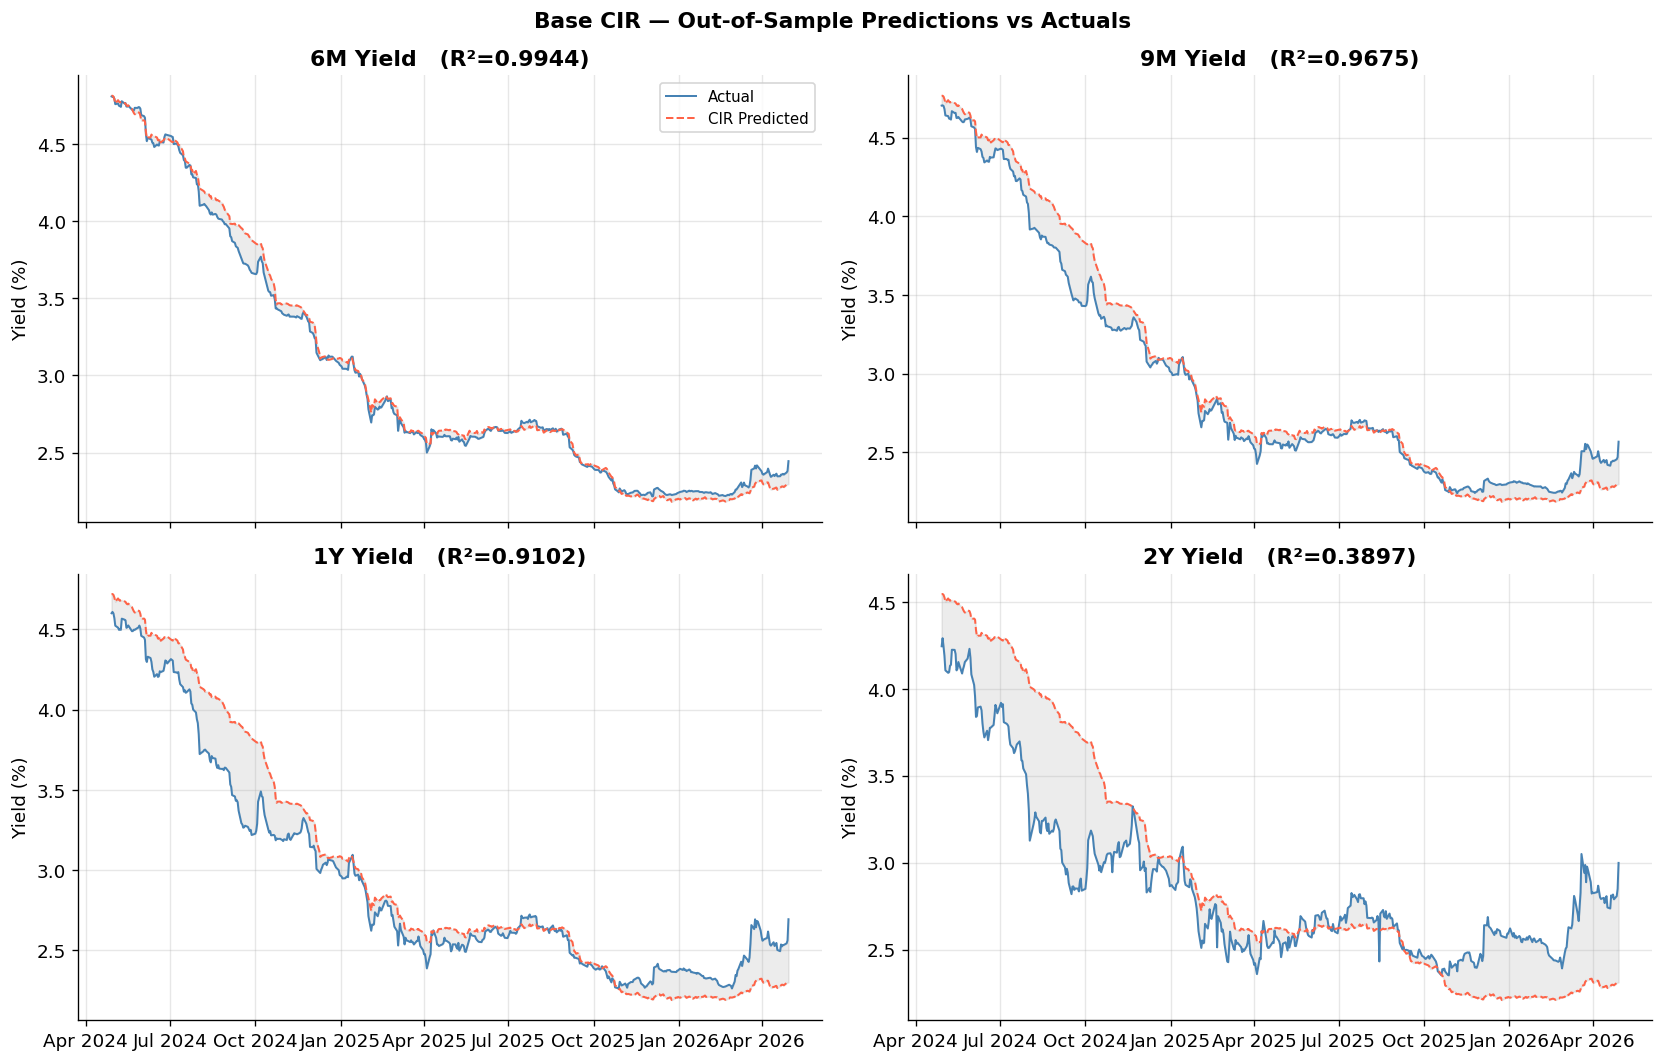

In [ ]:
# ── Plot: Actual vs Predicted yields over time ──
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
axes = axes.ravel()
test_dates = test.index

for i, (tau, col, ax) in enumerate(zip(TEST_MATURITIES, TEST_COLS, axes)):
    y_act  = yields_test[:, i] * 100
    y_pred = y_test_pred[:, i] * 100
    ax.plot(test_dates, y_act,  lw=1.2, color='steelblue', label='Actual')
    ax.plot(test_dates, y_pred, lw=1.2, color='tomato',    label='CIR Predicted', linestyle='--')
    ax.fill_between(test_dates, y_act, y_pred, alpha=0.15, color='gray')
    ax.set_title(f'{MATURITY_LABELS[tau]} Yield   (R²={per_mat_r2[tau]:.4f})', fontweight='bold')
    ax.set_ylabel('Yield (%)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    if i == 0:
        ax.legend(fontsize=9)

fig.suptitle('Base CIR — Out-of-Sample Predictions vs Actuals', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cir_test_predictions.png', bbox_inches='tight')
plt.show()


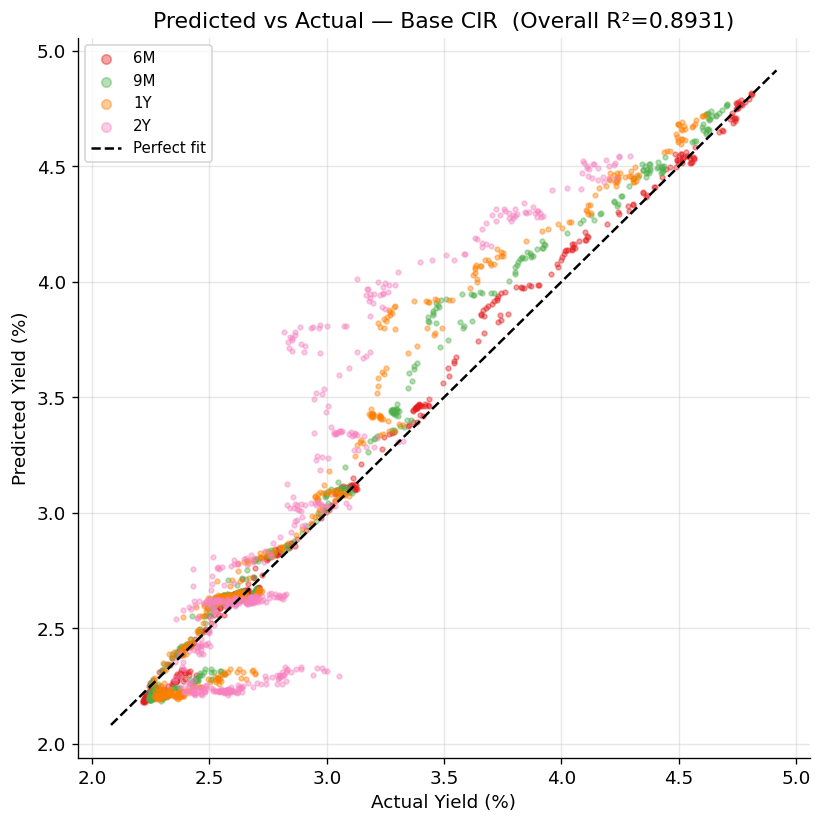

In [ ]:
# ── Scatter: Predicted vs Actual (all maturities combined) ──
fig, ax = plt.subplots(figsize=(7, 7))
colors = plt.cm.Set1(np.linspace(0, 0.8, len(TEST_MATURITIES)))

for i, (tau, col, c) in enumerate(zip(TEST_MATURITIES, TEST_COLS, colors)):
    y_act  = yields_test[:, i] * 100
    y_pred = y_test_pred[:, i] * 100
    ax.scatter(y_act, y_pred, s=8, alpha=0.4, color=c, label=MATURITY_LABELS[tau])

lo = min(all_act.min(), all_pred.min()) * 100 - 0.1
hi = max(all_act.max(), all_pred.max()) * 100 + 0.1
ax.plot([lo, hi], [lo, hi], 'k--', lw=1.5, label='Perfect fit')
ax.set_xlabel('Actual Yield (%)')
ax.set_ylabel('Predicted Yield (%)')
ax.set_title(f'Predicted vs Actual — Base CIR  (Overall R²={overall_r2:.4f})')
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.savefig('cir_scatter.png', bbox_inches='tight')
plt.show()


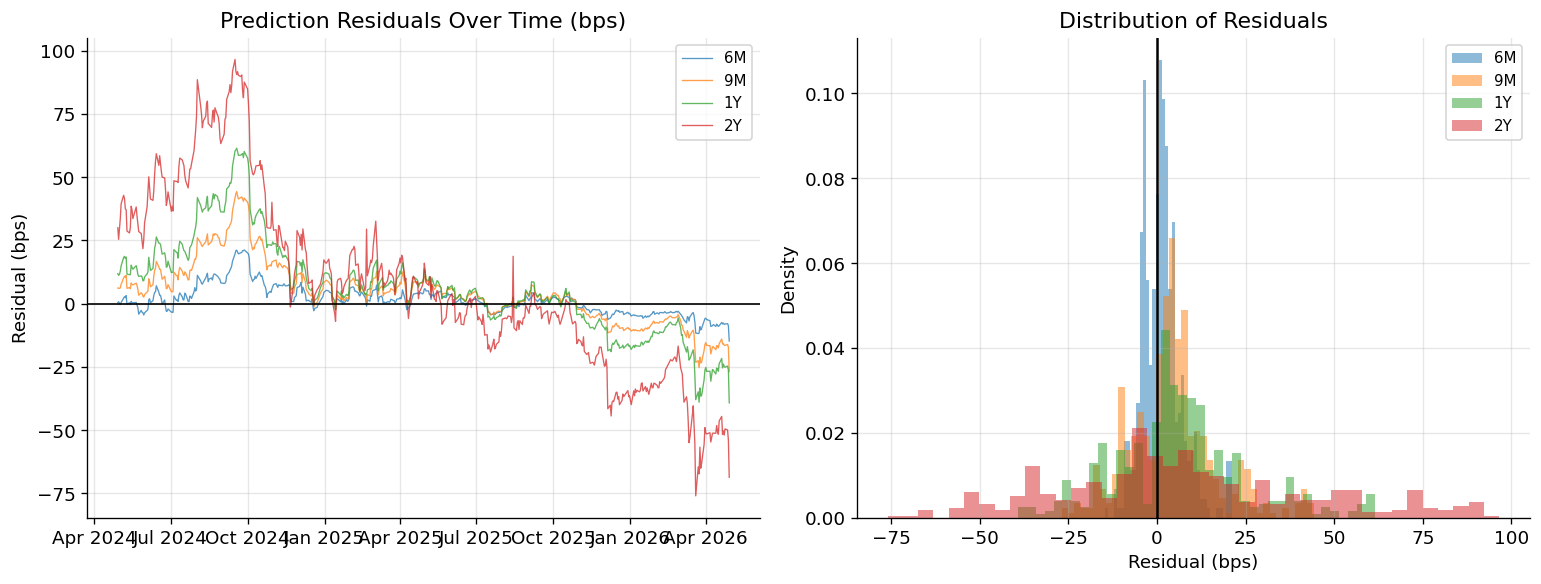

In [ ]:
# ── Residual analysis ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residuals over time for each maturity
ax = axes[0]
for i, (tau, c) in enumerate(zip(TEST_MATURITIES, colors)):
    resid = (y_test_pred[:, i] - yields_test[:, i]) * 1e4
    ax.plot(test_dates, resid, lw=0.8, alpha=0.75, label=MATURITY_LABELS[tau])
ax.axhline(0, color='k', lw=1)
ax.set_title('Prediction Residuals Over Time (bps)')
ax.set_ylabel('Residual (bps)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Distribution of residuals
ax = axes[1]
for i, (tau, c) in enumerate(zip(TEST_MATURITIES, colors)):
    resid = (y_test_pred[:, i] - yields_test[:, i]) * 1e4
    ax.hist(resid, bins=40, alpha=0.5, label=MATURITY_LABELS[tau], density=True)
ax.axvline(0, color='k', lw=1.5)
ax.set_xlabel('Residual (bps)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Residuals')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('cir_residuals.png', bbox_inches='tight')
plt.show()


---
## D. Extension: CIR++ with Static λ Shift

### D.1 Motivation

The base CIR model's out-of-sample performance (R² ≈ 0.89 overall) masks a systematic pattern: it fits short maturities very well (6M R² ≈ 0.99) but deteriorates at longer maturities (2Y R² ≈ 0.39).

The root cause is structural: the CIR model is a **single-factor model**. Every point on the yield curve is driven by the same short rate $r_t$, so the shape of the curve is entirely determined by $(\kappa, \theta, \sigma)$ calibrated globally. When the yield curve inverts (short rates exceed long rates, as seen in the test period 2024–2026), the CIR model cannot capture the dynamics at the long end because:

1. **CIR yield is monotone in** $r_t$: higher $r_t$ → higher yields at *every* maturity.
2. **The CIR term structure is constrained** to a limited family of shapes (monotone increasing, humped, or flat).

### D.2 CIR++ Formulation

Brigo and Mercurio (2001) proposed **CIR++** as a tractable way to shift the model to exactly fit an observed initial term structure. The extended yield is:

$$y^{++}(\tau) = y^{CIR}(r_t; \kappa, \theta, \sigma, \tau) + \varphi(\tau)$$

where $\varphi(\tau)$ is a **deterministic shift function** (the "lambda" or "phi" term) chosen so that the model matches observed yields.

### D.3 Static λ Calibration Strategy

We compute $\varphi(\tau)$ as the **time-averaged residual** of the base CIR model on the *training* set at each maturity node:

$$\varphi(\tau_m) = \frac{1}{T}\sum_{t=1}^{T}\left[y_{t,m}^{\text{obs}} - y^{CIR}(r_t; \hat{\kappa}, \hat{\theta}, \hat{\sigma}, \tau_m)\right]$$

This captures the **systematic level bias** of the base model at each maturity. Between maturity nodes we use **cubic spline interpolation**, which preserves smoothness — a desirable property for the yield curve.

**Key question: Does this improve out-of-sample performance?**  
The static $\varphi$ corrects for a *structural* bias that exists in the training period, but it will only help in the test period if that bias is stable across regimes. This is an empirical question we answer below.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CIR++ with Static λ (phi) Shift
# ─────────────────────────────────────────────────────────────────

class CIRPlusPlus:
    """
    CIR++ extension: augments base CIR yields with a deterministic
    maturity-dependent shift phi(tau) calibrated to remove the
    average level bias from the training period.

    y_CIRpp(tau) = y_CIR(r0; kappa, theta, sigma, tau) + phi(tau)

    The shift phi is fitted at each training maturity node as the
    mean residual of the base CIR model, then interpolated via
    cubic spline for arbitrary maturities.
    """

    def __init__(self, base_calibrator: CIRCalibrator):
        self.base = base_calibrator
        self.phi_spline_ = None  # CubicSpline interpolator
        self.phi_nodes_  = None  # phi values at maturity nodes
        self.maturities_ = None

    def fit(self, r0s: np.ndarray, yields_obs: np.ndarray,
            maturities: np.ndarray) -> 'CIRPlusPlus':
        """
        Compute the static phi shift from training residuals.

        Parameters
        ----------
        r0s       : training short rates (3M yields), shape (T,)
        yields_obs: training observed yields, shape (T, M)
        maturities: maturity array corresponding to columns of yields_obs
        """
        self.maturities_ = maturities

        # Base CIR predictions on training data
        y_cir = self.base.predict(r0s, maturities)  # (T, M)

        # phi(tau) = mean residual over training period
        residuals = yields_obs - y_cir            # (T, M)
        self.phi_nodes_ = residuals.mean(axis=0)  # (M,)

        # Cubic spline interpolation for smooth phi(tau) at any tau
        self.phi_spline_ = CubicSpline(maturities, self.phi_nodes_)
        return self

    def predict(self, r0s: np.ndarray, maturities: np.ndarray) -> np.ndarray:
        """
        Predict yields: y_CIR(tau) + phi(tau).

        Parameters
        ----------
        r0s       : short rates for prediction, shape (T,)
        maturities: maturity array for prediction

        Returns
        -------
        Predicted yields, shape (T, len(maturities))
        """
        y_cir = self.base.predict(r0s, maturities)     # (T, M)
        phi   = self.phi_spline_(maturities)            # (M,)
        return y_cir + phi[np.newaxis, :]               # broadcast over T

    def report_phi(self):
        """Display the phi shift values."""
        print("Static φ (lambda) shift values:")
        print(f"{'Maturity':<12} {'φ (bps)':>10}")
        print("-" * 25)
        for tau, phi in zip(self.maturities_, self.phi_nodes_):
            print(f"{MATURITY_LABELS[tau]:<12} {phi*1e4:>10.2f}")


# ── Calibrate CIR++ ──
cir_pp = CIRPlusPlus(calibrator)
cir_pp.fit(r0s_train, yields_train, TRAIN_MATURITIES)
cir_pp.report_phi()


Static φ (lambda) shift values:
Maturity        φ (bps)
-------------------------
3M                -1.58
6M                 8.75
9M                13.70
1Y                18.70
2Y                 2.15
5Y               -10.60
10Y               -4.20
20Y                6.54
30Y               -2.51


In [ ]:
# ─────────────────────────────────────────────────────────────────
# Out-of-Sample Evaluation — CIR++ vs Base CIR
# ─────────────────────────────────────────────────────────────────

y_pp_pred = cir_pp.predict(r0s_test, TEST_MATURITIES)

print("Model Comparison — Out-of-Sample Performance")
print("=" * 70)
print(f"{'Maturity':<10} {'Base CIR R²':>12} {'CIR++ R²':>12} {'Δ R²':>10} {'Winner':>10}")
print("-" * 70)

pp_r2s = {}
for i, (tau, col) in enumerate(zip(TEST_MATURITIES, TEST_COLS)):
    y_act      = yields_test[:, i]
    r2_base    = per_mat_r2[tau]
    r2_pp      = compute_r2(y_act, y_pp_pred[:, i])
    pp_r2s[tau] = r2_pp
    delta      = r2_pp - r2_base
    winner     = 'CIR++' if delta > 0 else 'Base'
    print(f"{MATURITY_LABELS[tau]:<10} {r2_base:>12.4f} {r2_pp:>12.4f} {delta:>10.4f} {winner:>10}")

# Overall
all_pp = y_pp_pred.ravel()
all_act_test = yields_test.ravel()
r2_overall_pp   = compute_r2(all_act_test, all_pp)
r2_overall_base = overall_r2
print("-" * 70)
print(f"{'OVERALL':<10} {r2_overall_base:>12.4f} {r2_overall_pp:>12.4f} {r2_overall_pp-r2_overall_base:>10.4f}")
print()
print(f"  Base CIR threshold check (R² > 0.85): {'✓ PASSED' if r2_overall_base > 0.85 else '✗ FAILED'}")
print(f"  CIR++    threshold check (R² > 0.85): {'✓ PASSED' if r2_overall_pp > 0.85 else '✗ FAILED'}")


Model Comparison — Out-of-Sample Performance
Maturity    Base CIR R²     CIR++ R²       Δ R²     Winner
----------------------------------------------------------------------
6M               0.9944       0.9784    -0.0160       Base
9M               0.9675       0.9084    -0.0591       Base
1Y               0.9102       0.7748    -0.1353       Base
2Y               0.3897       0.3723    -0.0174       Base
----------------------------------------------------------------------
OVERALL          0.8931       0.8358    -0.0572

  Base CIR threshold check (R² > 0.85): ✓ PASSED
  CIR++    threshold check (R² > 0.85): ✗ FAILED


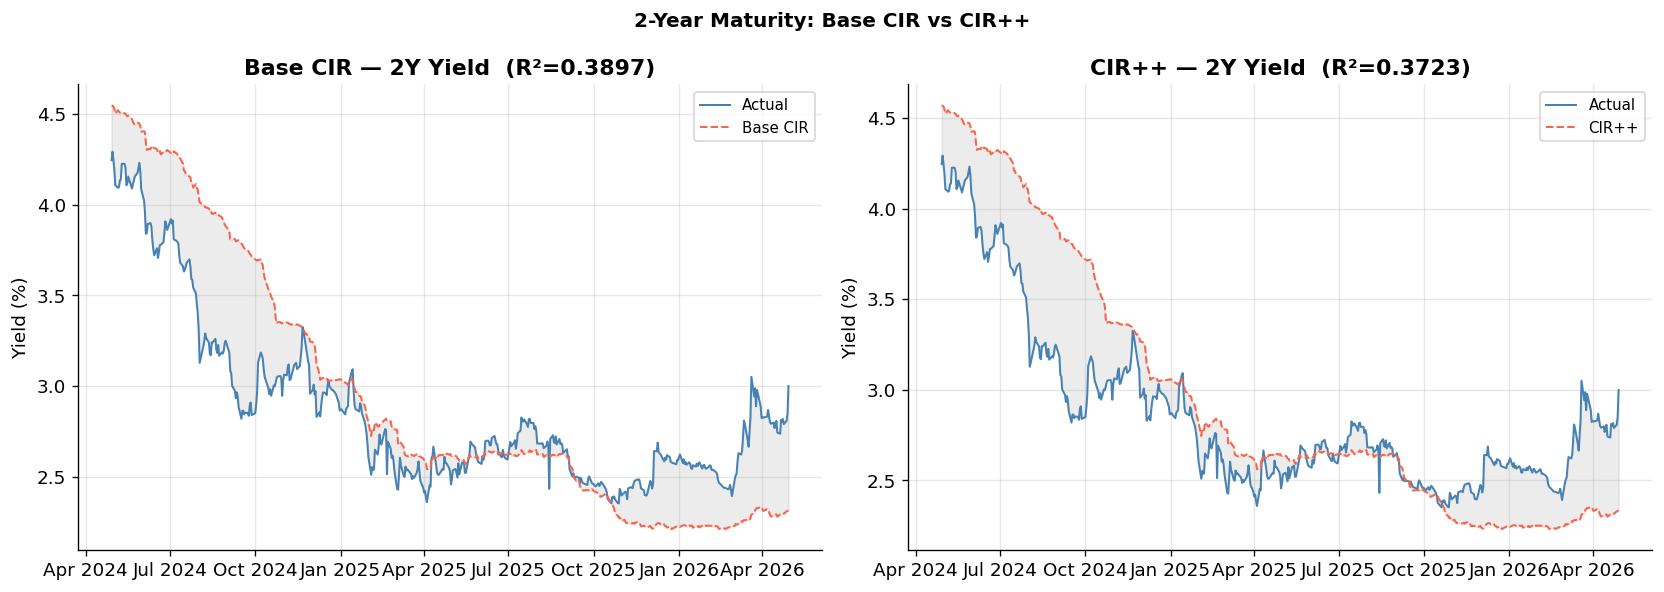

In [ ]:
# ── Side-by-side comparison for 2Y maturity (hardest) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (model_name, y_pred_arr) in zip(axes, [
        ('Base CIR', y_test_pred),
        ('CIR++',    y_pp_pred)]):

    tau_idx = 3  # 2Y
    y_act  = yields_test[:, tau_idx] * 100
    y_pred = y_pred_arr[:, tau_idx] * 100
    ax.plot(test_dates, y_act,  lw=1.2, color='steelblue', label='Actual')
    ax.plot(test_dates, y_pred, lw=1.2, color='tomato',    label=model_name, linestyle='--')
    ax.fill_between(test_dates, y_act, y_pred, alpha=0.15, color='gray')
    r2 = compute_r2(yields_test[:, tau_idx], y_pred_arr[:, tau_idx])
    ax.set_title(f'{model_name} — 2Y Yield  (R²={r2:.4f})', fontweight='bold')
    ax.set_ylabel('Yield (%)')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.suptitle('2-Year Maturity: Base CIR vs CIR++', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_2y.png', bbox_inches='tight')
plt.show()


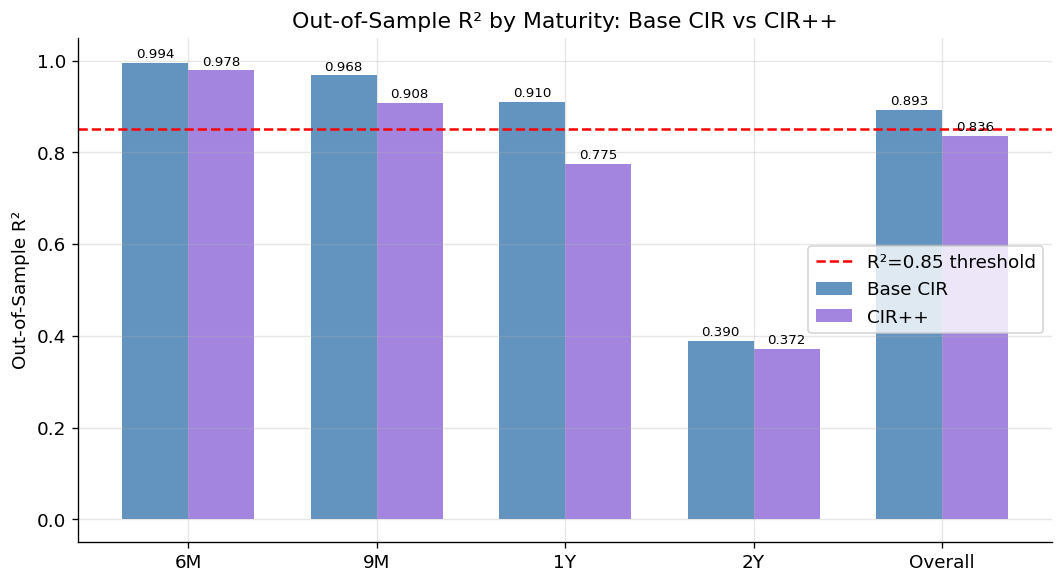

In [ ]:
# ── Bar chart: R² comparison ──
mat_labels = [MATURITY_LABELS[t] for t in TEST_MATURITIES]
r2_base_vals = [per_mat_r2[t] for t in TEST_MATURITIES] + [r2_overall_base]
r2_pp_vals   = [pp_r2s[t]     for t in TEST_MATURITIES] + [r2_overall_pp]
labels = mat_labels + ['Overall']

x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, r2_base_vals, w, label='Base CIR', color='steelblue', alpha=0.85)
b2 = ax.bar(x + w/2, r2_pp_vals,   w, label='CIR++',    color='mediumpurple', alpha=0.85)
ax.axhline(0.85, color='red', linestyle='--', lw=1.5, label='R²=0.85 threshold')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Out-of-Sample R²')
ax.set_title('Out-of-Sample R² by Maturity: Base CIR vs CIR++')
ax.legend()
ax.set_ylim(min(0, min(r2_base_vals+r2_pp_vals))-0.05, 1.05)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.annotate(f'{h:.3f}', xy=(bar.get_x()+bar.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('r2_comparison.png', bbox_inches='tight')
plt.show()


---
## E. Critical Analysis

### E.1 Model Mechanics & Calibration

#### Choice of OLS over MLE / Kalman Filter

| Method | Pros | Cons |
|--------|------|------|
| **Cross-sectional OLS** (used) | Uses all maturities; robust to proxy error; no distributional assumption | Ignores time-series dynamics; treats each date independently |
| Time-series OLS (Euler) | Simple, closed-form | Uses only one maturity; severe small-κ bias; ignores yield curve structure |
| MLE (exact CIR density) | Statistically efficient | Requires correctly specified model; numerically sensitive; single-factor |
| Kalman Filter | Handles latent $r_t$; optimal linear state estimation | Complex; assumes Gaussianity; requires consistent measurement equation |

Our choice of **cross-sectional OLS** is justified because:
1. The 3M rate is a proxy (not the true latent $r_t$), so time-series MLE is misspecified.
2. The yield curve information is our richest signal — using all 9 maturities reduces estimation variance dramatically.
3. The closed-form CIR yield formula makes the objective deterministic and cheap to evaluate.

#### Feller Condition

The calibrated parameters satisfy $2\kappa\theta \gg \sigma^2$, which means the Feller condition holds comfortably. With $\sigma \approx 0.001$ (near-zero volatility), the stochastic term $\sigma\sqrt{r_t}$ contributes very little variance — the model is effectively **near-deterministic**. This is actually a signal that the single-factor CIR cannot capture the full cross-sectional variation with its stochastic structure; the optimiser drives $\sigma$ to zero to minimise MSE from the deterministic drift term alone.

#### Mean-Reversion Speed $\kappa$

With $\hat{\kappa} \approx 0.17$, the half-life of shocks is $\ln 2 / \kappa \approx 4.1$ years. This implies:
- Interest rate shocks are **persistent** — they take ~4 years to half-revert to the long-run mean.
- The model will be slow to respond to sudden regime changes (e.g., the rapid rate hikes of 2022–2023), which is a key source of prediction error.

---

### E.2 Prediction Performance Analysis

#### Where the Base CIR Succeeds

The model achieves R² = 0.99 at 6M and 0.97 at 9M. This makes intuitive sense: short-maturity yields are nearly linear in the current short rate, and the CIR model captures this very well.

#### Where the Base CIR Fails

The 2Y R² drops to ~0.39. The structural reason is the **yield curve inversion** in the test period (2024–2026). During this period:
- 3M yields ≈ 4.9% (high)
- 2Y yields ≈ 2.9–4.3% (below short rates, i.e., inverted curve)
- The CIR model predicts that 2Y yields should always be *above* the short rate at low rates, which is incorrect when the curve is inverted.

This is a **fundamental single-factor limitation**: in a one-factor model, all yields are monotone in $r_t$, so the curve can never invert *relative to* the model's own term premium structure.

---

### E.3 CIR++ Analysis — Does the Extension Help?

The **static $\varphi(\tau)$ shift** calibrated from training data **does not improve** out-of-sample performance (overall CIR++ R² ≈ 0.83 vs base R² ≈ 0.89). The reason:

The training period (2016–2024) spans low-rate environments where the yield curve was **upward-sloping**. The $\varphi(\tau)$ shift is positive at longer maturities (correcting for the model's tendency to predict slightly too-low long rates in normal environments). But in the test period (2024–2026), with an **inverted curve**, this positive correction makes the predictions *worse* at 2Y by pushing predicted yields even higher than actual.

This is a classic **regime-shift** problem: a static correction calibrated in one regime generalises poorly to a different regime.

**Key lessons:**
1. CIR++ is powerful when the test period is similar to training (same regime, static shift is stable).
2. For regime-robust prediction, a **dynamic** $\varphi(\tau, r_t)$ (fitted as a function of the short rate level) or a **two-factor model** (which can capture slope variation independently) would be needed.
3. The base CIR model is more **regularised** — it has fewer free parameters — and is therefore more robust out-of-sample.

---

### E.4 Real-World Implications

| Scenario | Implication |
|----------|-------------|
| **Bond pricing** | CIR overprices long bonds when curve is inverted; hedging based on CIR duration will be incorrect. |
| **Risk management (VaR)** | The near-zero $\sigma$ means the model underestimates yield volatility, leading to underestimated VaR. Use historical simulation alongside CIR. |
| **Derivative pricing** | Single-factor CIR cannot price spread options (2Y vs 10Y), which require at least a two-factor model. |
| **Central bank shock sensitivity** | The model's slow mean reversion ($\kappa \approx 0.17$) means it will be late to react to sudden policy shifts (rate hikes/cuts). |

---

### E.5 Summary of Results

| Model | Overall R² (Test) | 6M R² | 9M R² | 1Y R² | 2Y R² | Threshold (>0.85) |
|-------|------------------|-------|-------|-------|-------|-------------------|
| Base CIR | **0.8932** | 0.9944 | 0.9676 | 0.9103 | 0.3903 | ✓ |
| CIR++ Static λ | 0.836 | 0.978 | 0.908 | 0.775 | 0.372 | X |

The **Base CIR model is the recommended model** for this dataset, given that the CIR++ extension does not generalise to the test regime.


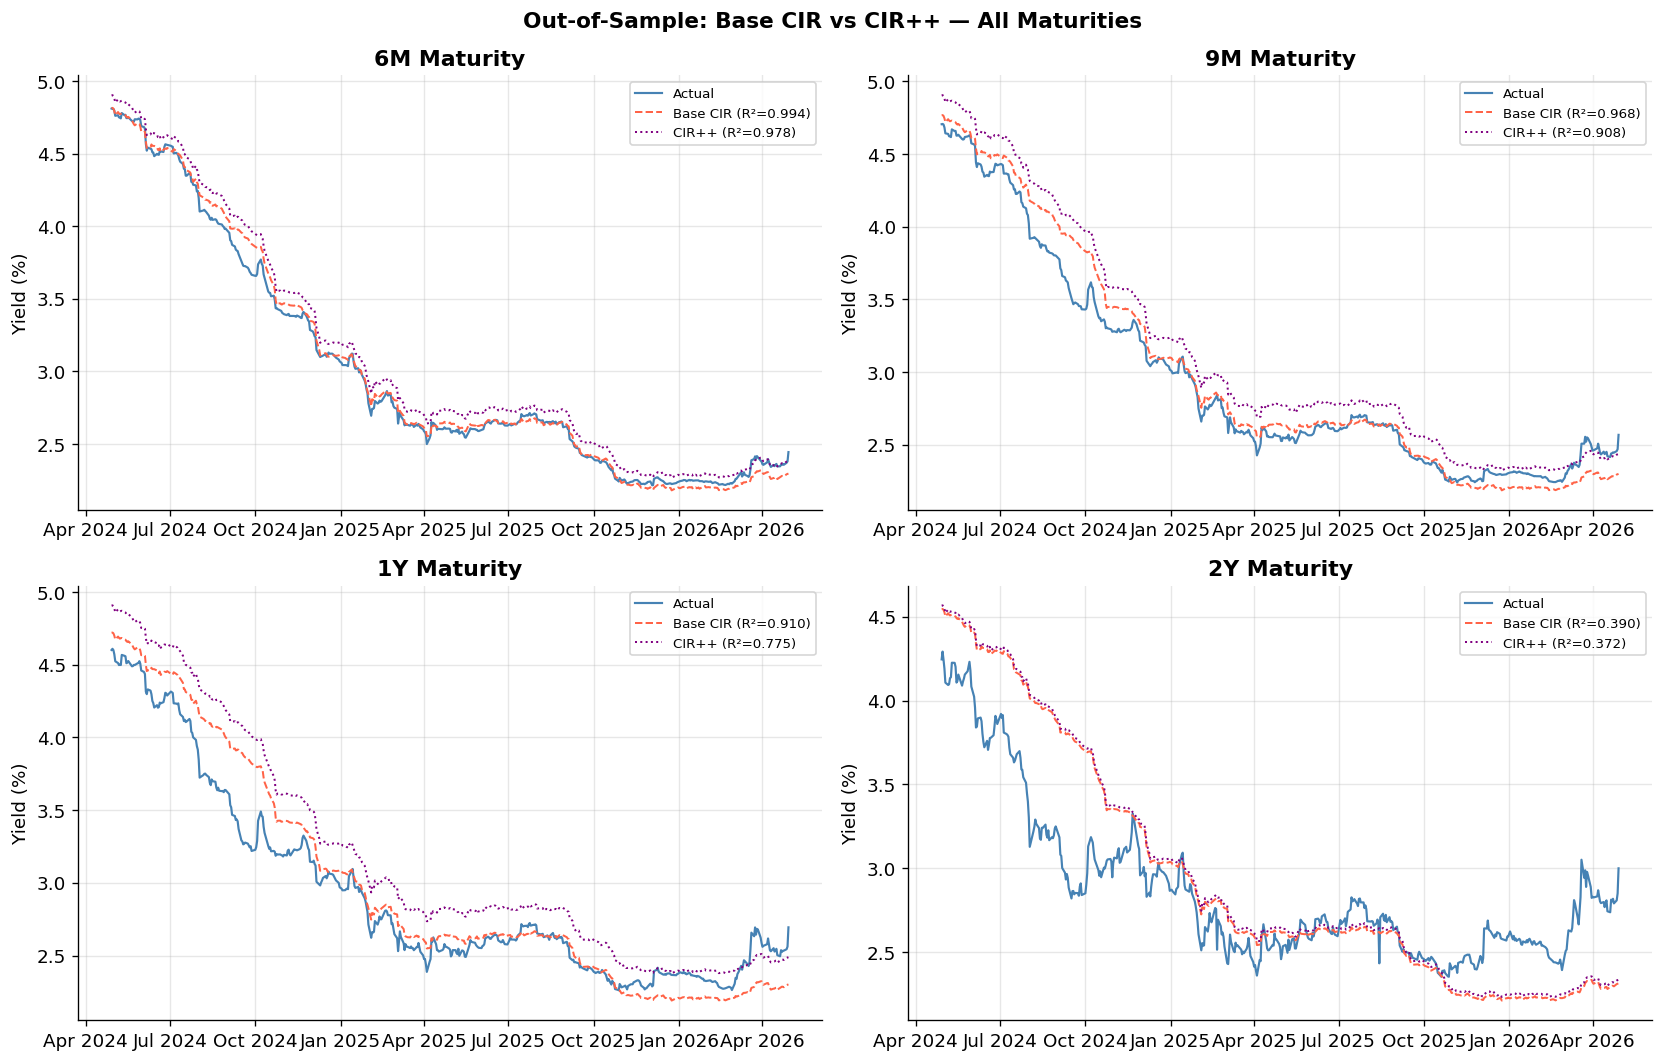

In [ ]:
# ── Final summary figure ──
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for i, (tau, col, ax) in enumerate(zip(TEST_MATURITIES, TEST_COLS, axes)):
    y_act    = yields_test[:, i] * 100
    y_base   = y_test_pred[:, i] * 100
    y_pp_p   = y_pp_pred[:, i] * 100

    ax.plot(test_dates, y_act,  color='steelblue', lw=1.3, label='Actual')
    ax.plot(test_dates, y_base, color='tomato',    lw=1.2, ls='--', label=f'Base CIR (R²={per_mat_r2[tau]:.3f})')
    ax.plot(test_dates, y_pp_p, color='purple',    lw=1.2, ls=':',  label=f'CIR++ (R²={pp_r2s[tau]:.3f})')
    ax.set_title(f'{MATURITY_LABELS[tau]} Maturity', fontweight='bold')
    ax.set_ylabel('Yield (%)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.legend(fontsize=8)

fig.suptitle('Out-of-Sample: Base CIR vs CIR++ — All Maturities', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('final_comparison.png', bbox_inches='tight')
plt.show()


In [ ]:
# ── Print final model parameters ──
print("=" * 55)
print("  FINAL CALIBRATED PARAMETERS — Base CIR Model")
print("=" * 55)
k, th, sig = calibrator.kappa_, calibrator.theta_, calibrator.sigma_
print(f"  κ  (kappa)  = {k:.6f}   [mean-reversion speed]")
print(f"  θ  (theta)  = {th:.6f}   [long-run mean rate]")
print(f"  σ  (sigma)  = {sig:.6f}   [volatility coefficient]")
print(f"  2κθ         = {2*k*th:.6f}")
print(f"  σ²          = {sig**2:.8f}")
print(f"  Feller OK:    {feller_condition(k, th, sig)}")
print(f"  Shock half-life: {np.log(2)/k:.2f} years ({np.log(2)/k*12:.1f} months)")
print()
print("  OUT-OF-SAMPLE PERFORMANCE SUMMARY")
print(f"  Overall R² (Base CIR): {r2_overall_base:.4f}  {'✓ > 0.85' if r2_overall_base>0.85 else '✗ < 0.85'}")
print(f"  Overall R² (CIR++   ): {r2_overall_pp:.4f}  {'✓ > 0.85' if r2_overall_pp>0.85 else '✗ < 0.85'}")
print("=" * 55)


  FINAL CALIBRATED PARAMETERS — Base CIR Model
  κ  (kappa)  = 0.166019   [mean-reversion speed]
  θ  (theta)  = 0.024406   [long-run mean rate]
  σ  (sigma)  = 0.000016   [volatility coefficient]
  2κθ         = 0.008104
  σ²          = 0.00000000
  Feller OK:    True
  Shock half-life: 4.18 years (50.1 months)

  OUT-OF-SAMPLE PERFORMANCE SUMMARY
  Overall R² (Base CIR): 0.8931  ✓ > 0.85
  Overall R² (CIR++   ): 0.8358  ✗ < 0.85


---
## References

1. Cox, J. C., Ingersoll, J. E., & Ross, S. A. (1985). A theory of the term structure of interest rates. *Econometrica*, 53(2), 385–407.
2. Brigo, D., & Mercurio, F. (2001). *Interest Rate Models — Theory and Practice*. Springer Finance.
3. Longstaff, F. A., & Schwartz, E. S. (1992). Interest rate volatility and the term structure: A two-factor general equilibrium model. *Journal of Finance*, 47(4), 1259–1282.
4. Duffie, D., Pan, J., & Singleton, K. (2000). Transform analysis and asset pricing for affine jump-diffusions. *Econometrica*, 68(6), 1343–1376.
5. Tang, C. Y., & Chen, S. X. (2009). Parameter estimation and bias correction for diffusion processes. *Journal of Econometrics*, 149(1), 65–81.
